In [39]:
%pip install pandas==1.5.3

  Using cached pandas-1.5.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
Using cached pandas-1.5.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.0 MB)
  Attempting uninstall: pandas
    Found existing installation: pandas 3.0.2
    Uninstalling pandas-3.0.2:
      Successfully uninstalled pandas-3.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
linearmodels 0.0.0 requires Cython>=3.0.10, which is not installed.
linearmodels 0.0.0 requires setuptools_scm[toml]<9.0.0,>=8.0.0, which is not installed.
xarray 2025.1.1 requires pandas>=2.1, but you have pandas 1.5.3 which is incompatible.
mapclassify 2.10.0 requires pandas>=2.1, but you have pandas 1.5.3 which is incompatible.
lifelines 0.30.0 requires pandas>=2.1, but you have pandas 1.5.3 which is incompatible.
geopandas 1.1.1 requires pandas>=2.0.0, but you have 

In [40]:
!pip install -r requirements.txt

  Using cached pandas-3.0.2-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
Using cached pandas-3.0.2-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (11.3 MB)
  Attempting uninstall: pandas
    Found existing installation: pandas 1.5.3
    Uninstalling pandas-1.5.3:
      Successfully uninstalled pandas-1.5.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
linearmodels 0.0.0 requires Cython>=3.0.10, which is not installed.
linearmodels 0.0.0 requires setuptools_scm[toml]<9.0.0,>=8.0.0, which is not installed.
ibis-framework 9.2.0 requires pandas<3,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
otter-grader 6.1.3 requires wrapt<2.0.0,>=1.16.0, but you have wrapt 2.1.1 which is incompatible.


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

In [42]:
def read_google_sheet(spreadsheet_id, sheet_name):
    """Read a Google Sheet tab as a DataFrame (sheet must be shared publicly)."""
    import urllib.parse
    encoded = urllib.parse.quote(sheet_name)
    url = f"https://docs.google.com/spreadsheets/d/{spreadsheet_id}/gviz/tq?tqx=out:csv&sheet={encoded}"
    df = pd.read_csv(url)
    print(f"  ✓ Loaded '{sheet_name}': {df.shape[0]} rows × {df.shape[1]} cols")
    return df

Tanzania_Data = '1LRe2bjhimuwrTXU8MpmQFH02MJegNRpmwNkY9T3HGqA'

In [43]:
print("=== Loading all datasets ===\n")

# Food Expenditures (both waves)
x19 = read_google_sheet(Tanzania_Data, 'Food Expenditures (2019-20)')
x20 = read_google_sheet(Tanzania_Data, 'Food Expenditures (2020-21)')
x = pd.concat([x19, x20], ignore_index=True)

# Food Prices (both waves)
p19 = read_google_sheet(Tanzania_Data, 'Food Prices (2019-20)')
p20 = read_google_sheet(Tanzania_Data, 'Food Prices (2020-21)')
p_raw = pd.concat([p19, p20], ignore_index=True)

# Household Characteristics
hh = read_google_sheet(Tanzania_Data, 'Household Characteristics')

# Food Composition Table
fct = read_google_sheet(Tanzania_Data, 'FCT')

# RDAs (US guidelines)
rda = read_google_sheet(Tanzania_Data, "RDA's")

# THM guidelines (Tanzania)
thm = read_google_sheet(Tanzania_Data, 'THM guidelines')

# Food Categories (maps foods to THM categories)
cats = read_google_sheet(Tanzania_Data, 'Catagories')

# Region Features (rural/urban indicator per household)
region_feat = read_google_sheet(Tanzania_Data, 'Region Features')

# Subsistence farming data
farming = read_google_sheet(Tanzania_Data, 'Sub. Farming')

print("\n=== All data loaded ===")

=== Loading all datasets ===

  ✓ Loaded 'Food Expenditures (2019-20)': 15581 rows × 5 cols
  ✓ Loaded 'Food Expenditures (2020-21)': 5728 rows × 5 cols
  ✓ Loaded 'Food Prices (2019-20)': 219 rows × 5 cols
  ✓ Loaded 'Food Prices (2020-21)': 245 rows × 5 cols
  ✓ Loaded 'Household Characteristics': 4709 rows × 19 cols
  ✓ Loaded 'FCT': 67 rows × 14 cols
  ✓ Loaded 'RDA's': 13 rows × 15 cols
  ✓ Loaded 'THM guidelines': 8 rows × 15 cols
  ✓ Loaded 'Catagories': 61 rows × 3 cols
  ✓ Loaded 'Region Features': 22433 rows × 4 cols
  ✓ Loaded 'Sub. Farming': 15 rows × 5 cols

=== All data loaded ===


**Deliverable A (Demand System)**

Demand estimate succeeded.
j
Beef                  0.424325
Bread                 0.133848
Citrus Fruits         1.143062
Coconuts              0.423582
Cooking Oil           0.324251
Eggs                  0.193519
Fish (fresh)          0.878667
Irish Potatoes        0.261055
Leafy Greens          0.303282
Maize (flour)         0.007951
Milk (fresh)          0.613150
Other Fruits          1.211548
Plantains             0.623253
Pulses                0.343060
Rice (husked)         0.407503
Ripe Bananas          1.124429
Salt                  0.174192
Soft drinks           0.280387
Sugar                 0.304220
Tea (dry)             0.266616
Vegetables (fresh)    0.496007
Wheat Flour           0.390250
Name: beta, dtype: float64
Median reference budget: 68723.69
Available goods: ['Beef', 'Bread', 'Citrus Fruits', 'Coconuts', 'Cooking Oil', 'Eggs', 'Fish (fresh)', 'Irish Potatoes', 'Leafy Greens', 'Maize (flour)', 'Milk (fresh)', 'Other Fruits', 'Plantains', 'Pulses', 'Rice (husked)', 'R

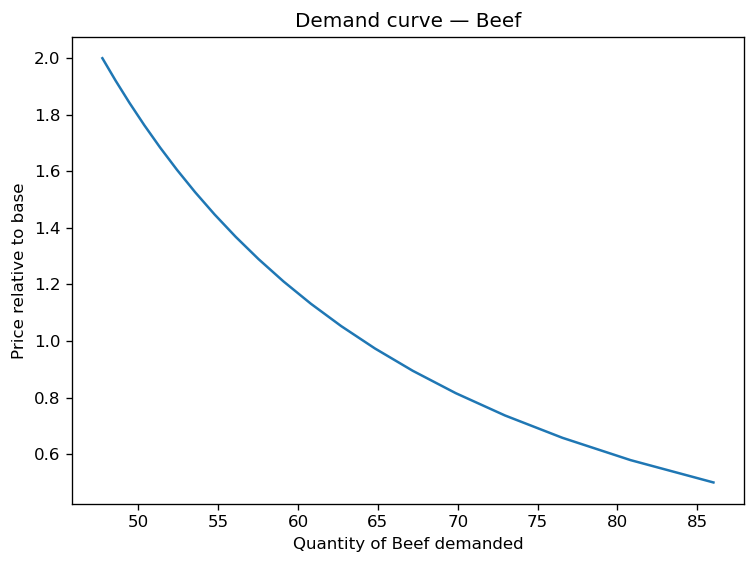

In [44]:
from cfe import Regression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

food_exp = x.copy()
food_exp.columns = food_exp.columns.str.strip()
food_exp["Expenditure"] = pd.to_numeric(food_exp["Expenditure"], errors="coerce")

y = (
    food_exp
    .set_index(["i", "t", "m", "j"])["Expenditure"]
    .groupby(["i", "t", "m", "j"])
    .sum()
)
y = y.replace(0, np.nan)
y = np.log(y)

hh_data = hh.copy()
hh_data.columns = hh_data.columns.str.strip()

d = hh_data.set_index(["i", "t", "m"])
d = d.apply(pd.to_numeric, errors="coerce").fillna(0)

r = Regression(y=y, d=d)
beta = r.get_beta()  
print("Demand estimate succeeded.")
print(beta)

xhat = r.predicted_expenditures()
xbar = xhat.groupby(["i", "t", "m"]).sum()
xref = xbar.quantile(0.5)  
print(f"Median reference budget: {xref:.2f}")

pbar = pd.Series(1.0, index=beta.index)


foods_in_xhat = set(xhat.index.get_level_values("j"))
missing = foods_in_xhat - set(pbar.index)
if missing:
    print(f"WARNING: foods in xhat not in pbar: {missing}")

print("Available goods:", list(beta.index))
use = beta.index[0]

def my_prices(p0, p=pbar, j=use):
    p = p.copy()
    p.loc[j] = p0
    return p

scale = np.linspace(0.5, 2, 20)
quantities, prices = [], []

for s in scale:
    new_price = pbar[use] * s
    q = r.demands(xref, my_prices(new_price))
    quantities.append(q[use])
    prices.append(s)

plt.figure()
plt.plot(quantities, prices)
plt.xlabel(f"Quantity of {use} demanded")
plt.ylabel("Price relative to base")
plt.title(f"Demand curve — {use}")
plt.tight_layout()
plt.show()

**Nutrient System**

In [45]:
import pandas as pd
import numpy as np

fct = read_google_sheet(Tanzania_Data, "FCT")
fct.columns = fct.columns.str.strip()
if "j" in fct.columns:
    fct = fct.set_index("j")
fct.columns.name = "n"
fct = fct.apply(pd.to_numeric, errors="coerce")

rdi = read_google_sheet(Tanzania_Data, "RDA's")
rdi.columns = rdi.columns.str.strip()
rdi = rdi.set_index(rdi.columns[0])
rdi.index.name = "n"
rdi.columns.name = "k"
rdi = rdi.apply(pd.to_numeric, errors="coerce")

qhat = xhat.unstack("j") / pbar
qhat = qhat.dropna(how="all")
qhat = qhat.loc[:, qhat.count() > 0]

fct_foods  = set(fct.index)
qhat_foods = set(qhat.columns)
overlap    = fct_foods & qhat_foods
print(f"FCT foods:  {len(fct_foods)},  qhat foods: {len(qhat_foods)},  overlap: {len(overlap)}")
if not overlap:
    raise ValueError("No food overlap between FCT and demand model — check food codes.")


fct_aligned, qhat_aligned = fct.align(qhat.T, axis=0, join="inner")
N = fct_aligned.T @ qhat_aligned 
N = N.loc[~N.index.duplicated()]
print("Predicted nutrient totals:")
display(N.head())


def nutrient_demand(xref, pbar, r=r, fct=fct):
    c = r.demands(xref, pbar)
    fct0, c0 = fct.align(c, axis=0, join="inner")
    N = fct0.T @ c0
    return N.loc[~N.index.duplicated()]


common_cols = rdi.columns.intersection(r.d.columns)
print(f"RDI columns:       {list(rdi.columns)}")
print(f"Household columns: {list(r.d.columns)}")
print(f"Common columns:    {list(common_cols)}")
if len(common_cols) == 0:
    raise ValueError("No common columns between RDI and household data — check column names.")

dbar    = r.d[common_cols].mean()
hh_rdi  = rdi[common_cols] @ dbar
print("Household nutrient requirements:")
display(hh_rdi)


def nutrient_adequacy_ratio(xref, pbar, dbar=dbar, rdi=rdi, days=7):
    common_cols = rdi.columns.intersection(dbar.index)
    hh_rdi_scaled = (
        rdi[common_cols]
        .replace("", 0)
        .apply(pd.to_numeric, errors="coerce")
        @ dbar[common_cols]
    ) * days
    return nutrient_demand(xref, pbar) / hh_rdi_scaled

nar = nutrient_adequacy_ratio(xref, pbar)
print("Nutrient adequacy ratio:")
display(nar)

  ✓ Loaded 'FCT': 67 rows × 14 cols
  ✓ Loaded 'RDA's': 13 rows × 15 cols
FCT foods:  67,  qhat foods: 22,  overlap: 22
Predicted nutrient totals:


i,1009-001-01,1025-001-02,1039-001-01,1078-001-01,1102-001-01,1142-001-01,1196-001-01,1213-001-01,1232-001-01,1248-001-01,...,9700-001-99,9712-001-99,9724-001-99,9736-001-99,9748-001-99,9760-001-99,9772-001-99,9784-001-99,9796-001-99,9808-001-99
t,2020-21,2020-21,2020-21,2020-21,2020-21,2020-21,2020-21,2020-21,2020-21,2020-21,...,2020-21,2020-21,2020-21,2020-21,2020-21,2020-21,2020-21,2020-21,2020-21,2020-21
m,Mainland Rural,Mainland Other Urban,Mainland Other Urban,Mainland Rural,Mainland Rural,Dar Es Salaam,Dar Es Salaam,Dar Es Salaam,Dar Es Salaam,Dar Es Salaam,...,Mainland Other Urban,Mainland Other Urban,Mainland Other Urban,Mainland Other Urban,Mainland Other Urban,Mainland Other Urban,Mainland Other Urban,Mainland Other Urban,Mainland Other Urban,Mainland Other Urban
n,,,,,,,,,,,,,,,,,,,,,
Energy,1.631883e+08,6.943055e+07,1.480421e+08,1.804745e+08,1.148040e+08,1.065541e+08,1.690428e+08,1.475285e+08,2.139710e+08,8.343029e+07,...,1.331361e+08,2.125457e+08,1.333373e+08,1.289495e+08,1.282357e+08,1.733736e+08,1.333126e+08,9.359000e+07,1.621702e+08,1.769890e+08
Protein,5.731459e+06,2.313374e+06,5.318633e+06,5.466857e+06,3.132408e+06,3.529901e+06,5.970367e+06,5.333519e+06,7.037218e+06,2.951795e+06,...,3.862664e+06,8.657130e+06,5.210341e+06,4.115540e+06,5.185958e+06,7.339101e+06,4.115527e+06,3.148971e+06,6.839421e+06,5.777729e+06
Vitamin A,4.761390e+07,2.461324e+07,4.736513e+07,4.149329e+07,2.231908e+07,5.080376e+07,5.777548e+07,6.594980e+07,9.842048e+07,4.234640e+07,...,3.123427e+07,7.103436e+07,4.411222e+07,4.016482e+07,5.009189e+07,5.705851e+07,3.224397e+07,2.254072e+07,4.821861e+07,4.822719e+07
Vitamin D,7.499411e+05,2.523330e+05,7.605437e+05,5.056224e+05,1.725728e+05,4.176425e+05,8.574594e+05,9.333717e+05,8.831833e+05,3.350544e+05,...,2.751329e+05,1.888658e+06,9.882821e+05,7.148080e+05,8.134728e+05,1.647881e+06,4.178318e+05,2.700441e+05,1.405632e+06,9.064157e+05
Vitamin E,4.488836e+05,2.043842e+05,4.455960e+05,4.429044e+05,3.093792e+05,2.808635e+05,4.135331e+05,4.358840e+05,3.791197e+05,1.985577e+05,...,2.845418e+05,6.386354e+05,4.152612e+05,3.641567e+05,3.324554e+05,5.252435e+05,3.071809e+05,2.064278e+05,5.241813e+05,4.985445e+05


RDI columns:       ['Males 00-03', 'Females 00-03', 'Males 04-08', 'Females 04-08', 'Males 09-13', 'Females 09-13', 'Males 14-18', 'Females 14-18', 'Males 19-30', 'Females 19-30', 'Males 31-50', 'Females 31-50', 'Males 51-99', 'Females 51-99']
Household columns: ['Males 00-03', 'Females 00-03', 'Males 04-08', 'Females 04-08', 'Males 09-13', 'Females 09-13', 'Males 14-18', 'Females 14-18', 'Males 19-30', 'Females 19-30', 'Males 31-50', 'Females 31-50', 'Males 51-99', 'Females 51-99', 'hh size', 'log HSize']
Common columns:    ['Males 00-03', 'Females 00-03', 'Males 04-08', 'Females 04-08', 'Males 09-13', 'Females 09-13', 'Males 14-18', 'Females 14-18', 'Males 19-30', 'Females 19-30', 'Males 31-50', 'Females 31-50', 'Males 51-99', 'Females 51-99']
Household nutrient requirements:


n
Energy          9612.090680
Protein          216.458438
Vitamin A       3606.045340
Vitamin D        106.838791
Vitamin E         67.413098
Vitamin C        328.136020
Vitamin B-6        6.020151
Vitamin B-12      10.855164
Calcium         5822.670025
Magnesium       1555.667506
Iron              58.934509
Zinc              43.677582
Fiber            134.569270
dtype: float64

Nutrient adequacy ratio:


n
Energy           730.027135
Protein          839.127626
Vitamin A        715.391481
Vitamin D        578.934026
Vitamin E        990.465852
Vitamin C       7545.239736
Vitamin B-6     2947.730943
Vitamin B-12     552.873312
Calcium          268.979863
Magnesium       1107.776112
Iron             329.287653
Zinc             204.582132
Fiber           1374.433337
dtype: float64